# Spectrogram Analysis and Recommendation System
This notebook analyzes audio previews using `scipy.signal.spectrogram`, extracts frequency band features, and builds a recommendation system based on cosine similarity.

In [1]:
# %pip install scipy numpy pandas scikit-learn librosa tqdm

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
from scipy import signal
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [3]:
NUM_SONGS_TO_PROCESS = 402_088
PREVIEWS_DIR = '/home/build/martin/spotify_v2/data/previews'
DATASET_PATH = '/home/build/martin/spotify_v2/spotify_411k.parquet'
CHECKPOINT_DIR = '/home/build/martin/spotify_v2/checkpoints_spectrogram'
CHECKPOINT_N = 1000
OUTPUT_PARQUET_PATH = '/home/build/martin/spotify_v2/spectrogram_features.parquet'

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [4]:
def get_spectrogram_features(file_path):
    try:
        # Load audio file. librosa automatically delegates to audioread for mp3
        y, sr = librosa.load(file_path, sr=22050, mono=True)
        # Generate spectrogram using scipy
        f, t, Sxx = signal.spectrogram(y, fs=sr)
        # Return mean and std energy per frequency bin as a feature vector
        mean_energy = np.mean(Sxx, axis=1)
        std_energy = np.std(Sxx, axis=1)
        return np.concatenate([mean_energy, std_energy])
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def load_processed_ids(checkpoint_dir):
    from pathlib import Path
    done = set()
    for p in Path(checkpoint_dir).glob("checkpoint_*.parquet"):
        try:
            done.update(pd.read_parquet(p, columns=['track_id'])['track_id'].tolist())
        except Exception:
            pass
    print(f"Resuming — {len(done):,} already done")
    return done

def flush_checkpoint(features_list, track_ids, checkpoint_dir, idx):
    from pathlib import Path
    if not features_list:
        return
    num_features = len(features_list[0])
    feature_cols = [f'spec_feat_{i}' for i in range(num_features)]
    df = pd.DataFrame(features_list, columns=feature_cols)
    df['track_id'] = track_ids
    path = Path(checkpoint_dir) / f"checkpoint_{idx:05d}.parquet"
    df.to_parquet(path, index=False, compression='snappy')
    print(f"  Checkpoint {idx:05d} — {len(df):,} rows → {path.name}")

def merge_checkpoints(checkpoint_dir, output_path):
    from pathlib import Path
    parts = sorted(Path(checkpoint_dir).glob("checkpoint_*.parquet"))
    print(f"Merging {len(parts)} checkpoint files …")
    if not parts:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
    df.drop_duplicates(subset='track_id', inplace=True)
    df.to_parquet(output_path, index=False, compression='snappy')
    print(f"Final → {output_path}  ({len(df):,} rows)")
    return df


In [5]:
# Get list of mp3 files
all_preview_files = glob.glob(os.path.join(PREVIEWS_DIR, '*.mp3'))
all_preview_files = all_preview_files[:NUM_SONGS_TO_PROCESS]

done_ids = load_processed_ids(CHECKPOINT_DIR)
todo_files = [f for f in all_preview_files if os.path.basename(f).replace('.mp3', '') not in done_ids]

print(f"Total files: {len(all_preview_files):,} | Already processed: {len(done_ids):,} | To process: {len(todo_files):,}")

features_list = []
track_ids = []
checkpoint_idx = len(glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_*.parquet')))

for i, file_path in enumerate(tqdm(todo_files)):
    track_id = os.path.basename(file_path).replace('.mp3', '')
    features = get_spectrogram_features(file_path)
    if features is not None:
        features_list.append(features)
        track_ids.append(track_id)
    
    # Batch checkpoint
    if (len(features_list) >= CHECKPOINT_N):
        flush_checkpoint(features_list, track_ids, CHECKPOINT_DIR, checkpoint_idx)
        checkpoint_idx += 1
        features_list = []
        track_ids = []

# Final flush
if features_list:
    flush_checkpoint(features_list, track_ids, CHECKPOINT_DIR, checkpoint_idx)
    checkpoint_idx += 1

df_features = merge_checkpoints(CHECKPOINT_DIR, OUTPUT_PARQUET_PATH)

if not df_features.empty:
    feature_cols = [c for c in df_features.columns if c.startswith('spec_feat_')]
else:
    feature_cols = []
    
print(f"Successfully processed total {len(df_features)} tracks.")
df_features.head()


Resuming — 402,088 already done
Total files: 402,088 | Already processed: 402,088 | To process: 0


0it [00:00, ?it/s]

Merging 403 checkpoint files …


Final → /home/build/martin/spotify_v2/spectrogram_features.parquet  (402,088 rows)
Successfully processed total 402088 tracks.


,spec_feat_0,spec_feat_1,spec_feat_2,spec_feat_3,spec_feat_4,spec_feat_5,spec_feat_6,spec_feat_7,spec_feat_8,spec_feat_9,...,spec_feat_249,spec_feat_250,spec_feat_251,spec_feat_252,spec_feat_253,spec_feat_254,spec_feat_255,spec_feat_256,spec_feat_257,track_id
0,0.000004,0.000222,0.000051,0.000015,0.000007,0.000005,0.000004,0.000003,0.000003,0.000002,...,1.732505e-07,1.495786e-07,8.148560e-08,2.571843e-08,5.845014e-09,1.834908e-09,5.563925e-10,3.197384e-10,1.444920e-10,0x7IgG3pJHBUoULcsaPFpr
1,0.000008,0.000463,0.000067,0.000020,0.000009,0.000006,0.000014,0.000010,0.000003,0.000003,...,7.224862e-08,1.211405e-07,1.182204e-07,3.420323e-08,4.519077e-09,1.679055e-09,6.050356e-10,2.688768e-10,1.306897e-10,0TwCiWSPzZ0BcaQYb0UVKw
2,0.000009,0.000604,0.000101,0.000050,0.000055,0.000042,0.000033,0.000030,0.000026,0.000029,...,4.251170e-07,4.276581e-07,2.270999e-07,8.943017e-08,2.428303e-08,5.385353e-09,1.755945e-09,9.241397e-10,4.139269e-10,0QzunfX8JmHwfcbv04VvmT
3,0.000006,0.000298,0.000089,0.000057,0.000045,0.000070,0.000039,0.000023,0.000018,0.000027,...,2.631199e-07,2.018548e-07,1.062153e-07,4.155208e-08,1.122317e-08,2.656524e-09,9.123098e-10,5.024517e-10,2.227543e-10,4f6PfM9PbgGbw18yAmfUyr
4,0.000003,0.000097,0.000044,0.000080,0.000036,0.000034,0.000106,0.000069,0.000033,0.000032,...,3.514249e-07,2.563812e-07,2.609905e-07,1.422979e-07,3.989585e-08,1.231774e-08,2.831407e-09,1.588615e-09,7.142942e-10,65OB3BOzCz4kpenuKT8An2


In [6]:
# Features are now merged and saved in the previous cell
print(f'Final features parquet: {OUTPUT_PARQUET_PATH}')

Final features parquet: /home/build/martin/spotify_v2/spectrogram_features.parquet


In [7]:
# Load Main Dataset
df_main = pd.read_parquet(DATASET_PATH)

# Determine the track ID column in main dataset
join_col = 'track_id' if 'track_id' in df_main.columns else 'id'

# Merge features with main dataset
df_merged = pd.merge(df_main, df_features, left_on=join_col, right_on='track_id', how='inner')
print(f"Merged dataset shape: {df_merged.shape}")
df_merged.head()


Merged dataset shape: (402088, 297)


,track_id,original_name,original_artist,id,name,title,uri,type,duration,duration_ms,...,spec_feat_248,spec_feat_249,spec_feat_250,spec_feat_251,spec_feat_252,spec_feat_253,spec_feat_254,spec_feat_255,spec_feat_256,spec_feat_257
0,2gCF9TZUNUnUXH9YWQS7Ea,Wicked Wonderland - Extended Mix,Tungevaag,2gCF9TZUNUnUXH9YWQS7Ea,Wicked Wonderland - Extended Mix,Wicked Wonderland - Extended Mix,spotify:track:2gCF9TZUNUnUXH9YWQS7Ea,track,309389.0,309389.0,...,2.357259e-07,1.147947e-07,9.638407e-08,6.287316e-08,3.714198e-08,5.680166e-09,1.394151e-09,4.909894e-10,2.834330e-10,1.268059e-10
1,6qYkYBylocBlUEcNPzjqCJ,Where Are You,Sako Isoyan,6qYkYBylocBlUEcNPzjqCJ,Where Are You,Where Are You,spotify:track:6qYkYBylocBlUEcNPzjqCJ,track,378627.0,378627.0,...,1.567196e-07,3.511993e-07,3.227815e-07,2.021198e-07,5.557690e-08,3.005555e-08,4.290769e-09,1.470155e-09,8.402935e-10,3.618627e-10
2,7KnCHIPDYw7NmYVWewBFwJ,The Drop,Hybrid,7KnCHIPDYw7NmYVWewBFwJ,The Drop,The Drop,spotify:track:7KnCHIPDYw7NmYVWewBFwJ,track,176586.0,176586.0,...,5.664607e-09,2.527461e-09,6.117392e-09,1.642257e-09,3.310039e-10,1.265881e-10,3.534501e-11,1.440737e-11,7.359903e-12,3.109258e-12
3,1Ypq3qbpf1RXHFMemhAKPp,Pick Your Poison (feat. Kay) - Swizzymack Remix,Datsik,1Ypq3qbpf1RXHFMemhAKPp,Pick Your Poison (feat. Kay) - Swizzymack Remix,Pick Your Poison (feat. Kay) - Swizzymack Remix,spotify:track:1Ypq3qbpf1RXHFMemhAKPp,track,135106.0,135106.0,...,7.682360e-07,8.697158e-07,4.555393e-07,2.030807e-07,1.063316e-07,1.894294e-08,5.663772e-09,2.407313e-09,1.236169e-09,5.281608e-10
4,3gwaNmNQDrE03RZnMcwDNH,Just Dance,Kids Dance Party,3gwaNmNQDrE03RZnMcwDNH,Just Dance,Just Dance,spotify:track:3gwaNmNQDrE03RZnMcwDNH,track,346280.0,346280.0,...,4.585237e-07,3.693186e-07,4.510275e-07,1.306083e-07,3.190523e-08,9.287133e-09,2.658632e-09,1.039835e-09,5.828461e-10,2.374312e-10


In [8]:
# Recommendation System based on spectrogram features
def get_recommendations(target_track_id, df, features_columns, top_n=5):
    # Determine ID column in merged df
    id_col = 'track_id' if 'track_id' in df.columns else 'id'
    
    if target_track_id not in df[id_col].values:
        return "Track ID not found in the merged dataset."
    
    # Extract feature matrix
    feature_matrix = df[features_columns].values
    
    # Get target track features
    target_idx = df.index[df[id_col] == target_track_id].tolist()[0]
    target_features = feature_matrix[target_idx].reshape(1, -1)
    
    # Calculate cosine similarity
    similarities = cosine_similarity(target_features, feature_matrix)[0]
    
    # Add similarities to a temp dataframe
    df_sim = df.copy()
    df_sim['similarity'] = similarities
    
    # Sort and get top N (excluding the target track itself)
    recommendations = df_sim[df_sim[id_col] != target_track_id].sort_values(by='similarity', ascending=False).head(top_n)
    
    # Select columns to display
    display_cols = [id_col, 'similarity']
    for col in ['name', 'track_name', 'artists', 'artist_name']:
         if col in df_sim.columns:
             display_cols.append(col)
             
    return recommendations[display_cols]


# Example: Get recommendations for the first valid track in our processed subset
if not df_merged.empty:
    id_col = 'track_id' if 'track_id' in df_merged.columns else 'id'
    sample_track = df_merged.iloc[0][id_col]
    sample_track_name = df_merged.iloc[0].get('track_name', df_merged.iloc[0].get('name', 'Unknown Track'))
    print(f"Recommendations for Track ID: {sample_track} - Track Name: {sample_track_name}")
    display(get_recommendations(sample_track, df_merged, feature_cols))


Recommendations for Track ID: 2gCF9TZUNUnUXH9YWQS7Ea - Track Name: Wicked Wonderland - Extended Mix


,track_id,similarity,name,track_name,artists,artist_name
283499,2uKMCkIkmsPkrfSwTGcuzq,0.999160,Bruce Banner - Audio Pervert Remix,Bruce Banner - Audio Pervert Remix,"[{'id': '3tKsgOYV3Cwl7Fyzr2S6Ud', 'name': 'Has...",Hashback Hashish
370911,1mclnPKGEDY28YuiKEYldM,0.999122,Caliphate,Caliphate - Original Mix,"[{'id': '0h2BiRVGmUGsK7HtkC1vLl', 'name': 'Col...",Colombo
114000,2JmKUraYV4vDo6urq0Kucp,0.999113,Helluva Life,Helluva Life,"[{'id': '3nHKeOa45XrUplL3NiGy7E', 'name': 'Fra...",FrankJavCee
34695,5g9gZGiXlk747pESQzmmRT,0.999084,Hälsa Gud,Hälsa Gud,"[{'id': '04HqRx07Bv9gh7rsrMTqs7', 'name': 'Mis...",Miss Li
48258,6FDtusHKRJdlHLApla3VSa,0.999077,Capricorn,Capricorn,"[{'id': '2vf4pRsEY6LpL5tKmqWb64', 'name': 'Eld...",Elderbrook


## Visualizing Sample Spectrograms

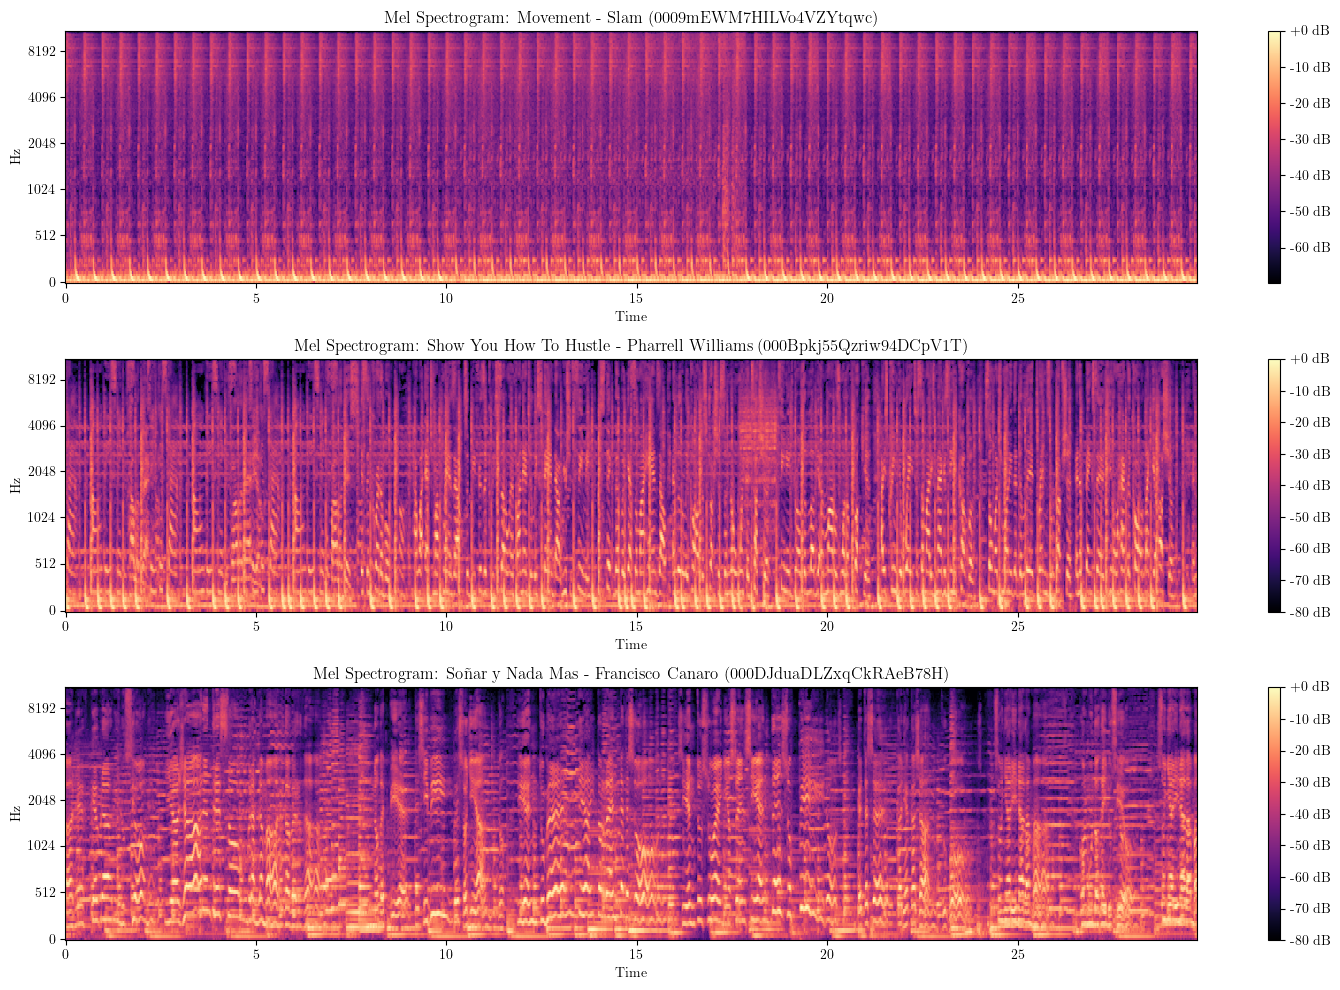

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Load metadata first to find song names and artists
metadata_path = '/home/build/martin/spotify_v2/spotify_411k.parquet'
df_meta = pd.read_parquet(metadata_path, columns=['track_id', 'track_name', 'artist_name'])
df_meta['track_id'] = df_meta['track_id'].astype(str)
meta_dict = df_meta.set_index('track_id')[['track_name', 'artist_name']].to_dict('index')

previews_dir = '/home/build/martin/spotify_v2/data/previews'
mp3_files = sorted(list(Path(previews_dir).glob('*.mp3')))[:3]

if not mp3_files:
    print(f'No mp3 files found in {previews_dir}')
else:
    plt.figure(figsize=(15, 10))
    for i, file_path in enumerate(mp3_files):
        try:
            tid = file_path.stem
            info = meta_dict.get(tid, {'track_name': 'Unknown', 'artist_name': 'Unknown'})
            track_name = info['track_name']
            artist_name = info['artist_name']
            
            y, sr = librosa.load(file_path, sr=22050)
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            S_dB = librosa.power_to_db(S, ref=np.max)
            
            plt.subplot(len(mp3_files), 1, i+1)
            librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f'Mel Spectrogram: {track_name} - {artist_name} ({tid})')
        except Exception as e:
            print(f'Error processing {file_path.name}: {e}')
    
    plt.tight_layout()
    plt.show()